In [ ]:
!git clone https://github.com/ultralytics/yolov5
%cd yolov5
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17752, done.
remote: Counting objects: 100% (108/108), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 17752 (delta 66), reused 36 (delta 36), pack-reused 17644 (from 4)
Receiving objects: 100% (17752/17752), 17.13 MiB | 22.06 MiB/s, done.
Resolving deltas: 100% (12056/12056), done.
/content/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 35.6 MB/s eta 0:00:00


In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="My_key")
project = rf.workspace("softeng-wfoaa").project("butterflies-izhdz")
version = project.version(1)
dataset = version.download("yolov5")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 88.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 138.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Butterflies-1 in yolov5pytorch:: 100%|██████████| 149/149 [00:00<00:00, 9292.96it/s]


In [ ]:
!python /content/yolov5/train.py \
  --img 640 \
  --batch 8 \
  --epochs 30 \
  --data {dataset.location}/data.yaml \
  --weights yolov5s.pt \
  --name butterfly_yolov5s

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2025-12-03 12:52:11.217198: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764766331.237301     771 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764766331.243570     771 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS wh

In [ ]:
!python /content/yolov5/detect.py \
  --weights /content/yolov5/runs/train/butterfly_yolov5s/weights/best.pt \
  --img 640 \
  --conf 0.3 \
  --source /content/yolov5/butterfly_test

detect: weights=['/content/yolov5/runs/train/butterfly_yolov5s/weights/best.pt'], source=/content/yolov5/butterfly_test, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.3, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_format=0, save_csv=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-450-g781b9d57 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
image 1/8 /content/yolov5/butterfly_test/0229b902.jpg: 448x640 3 butterflys, 32.3ms
image 2/8 /content/yolov5/butterfly_test/download (1).jpeg: 448x640 1 butterfly, 8.7ms
image 3/8 /content/yolov5/butterfly_test/download (2).jpeg: 448x640 1 butterfly, 8.7ms
image 4/8 /conte

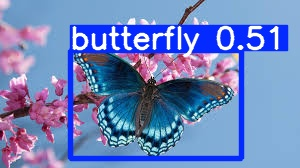

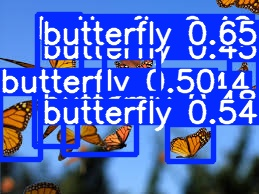

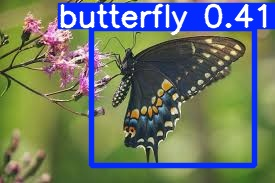

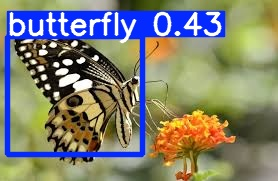

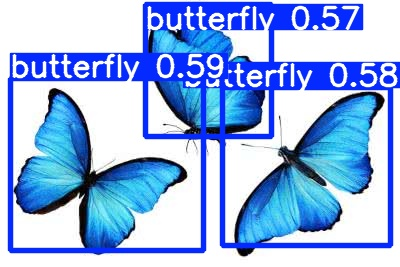

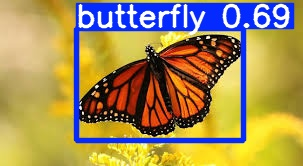

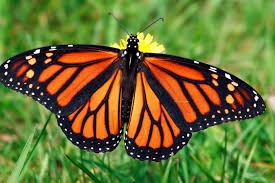

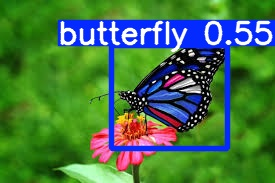

In [ ]:
import glob
from IPython.display import Image, display

for image_path in glob.glob('/content/yolov5/runs/detect/exp2/*.*'):
    display(Image(filename=image_path))